Project Overview

This project focuses on analyzing Amazon shopping reviews to understand customer sentiment and extract meaningful insights. Using Natural Language Processing (NLP) and Machine Learning techniques, we aim to classify reviews as positive, negative, or neutral and identify key trends in customer feedback

Dataset Description

The dataset contains structured Amazon product reviews with the following key columns:

Review ID: Unique identifier for each review

Username: Name/ID of the reviewer (anonymized if needed)

Content: Full text of the review

Score: Rating (1–5 stars, where 1=Negative, 5=Positive)

ThumbsUpCount: Number of helpful votes (usefulness indicator)





Objectives

Perform Exploratory Data Analysis (EDA) to understand review patterns.

Apply Text Preprocessing (cleaning, tokenization, stemming/lemmatization).

Train Machine Learning models (Logistic Regression, Random Forest, Decision Tree).

Compare model performance using metrics like accuracy, precision, recall, and F1-score.

In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ashishkumarak_amazon_shopping_reviews_daily_updated_path = kagglehub.dataset_download('ashishkumarak/amazon-shopping-reviews-daily-updated')

print('Data source import complete.')

Data source import complete.


**Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from nltk.corpus import stopwords
from textblob import Word, TextBlob
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from nltk.sentiment import SentimentIntensityAnalyzer
from warnings import filterwarnings
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, make_scorer, precision_score,recall_score,accuracy_score,f1_score
from sklearn.model_selection import StratifiedKFold, cross_validate
filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.2f' % x)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/amazon-shopping-reviews-daily-updated/amazon_reviews.csv


**Load Dataset**

In [3]:
df = pd.read_csv('/kaggle/input/amazon-shopping-reviews-daily-updated/amazon_reviews.csv')
df

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b6f9fe52-0c2a-4ffe-b7f5-c44b54736f01,Allen Li,this company needs to learn how to deliver ite...,1,0,NaN,2025-06-14 12:41:23,NaN
1,51c05309-b73a-48b0-83f4-fe46d0602cb5,Dede Lopresti,love my Amazon prime account. so much to offer...,5,0,28.21.6.100,2025-06-14 12:37:22,28.21.6.100
2,13447732-098d-4d6e-b9f2-ddb847fedaeb,Paul Walters,Constantly crashing or freezing. It's been fin...,4,0,30.8.0.100,2025-06-14 12:34:33,30.8.0.100
3,aa4b7892-9a19-4400-88da-b4b28e17aeb8,Jaime Botelho,convenient,5,0,30.11.0.100,2025-06-14 12:31:50,30.11.0.100
4,fbff5feb-392a-4289-87d7-4b2268cf7dc4,Ziteng Zeng,Can't buy anything. Keeps sending me emails li...,1,0,30.11.0.100,2025-06-14 12:28:20,30.11.0.100
...,...,...,...,...,...,...,...,...
74994,ac82191a-e776-42a0-8e30-91eabb763968,Mary Mora,Amazon Smile donates. Make sure you get all se...,5,0,26.1.2.100,2023-01-16 06:12:14,26.1.2.100
74995,3aa6af38-b044-4257-9cf3-b94c437da0ef,Marie Elliott,After having problems with the app and having ...,5,1,22.18.0.100,2021-09-24 12:01:29,22.18.0.100
74996,727ec38a-c633-48f4-a302-66e52740a43c,Dan Preston,"Used to be great. Got greedy, they ruined the ...",1,0,26.9.0.100,2023-05-15 18:27:24,26.9.0.100
74997,615a9643-cd36-4010-9a81-8763bac11ddf,Jhosh,New search bar location sucks. At least give m...,2,0,26.12.0.100,2023-06-11 15:24:08,26.12.0.100


**Data Preparing**

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74999 entries, 0 to 74998
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              74999 non-null  object
 1   userName              74994 non-null  object
 2   content               74993 non-null  object
 3   score                 74999 non-null  int64 
 4   thumbsUpCount         74999 non-null  int64 
 5   reviewCreatedVersion  66601 non-null  object
 6   at                    74999 non-null  object
 7   appVersion            66601 non-null  object
dtypes: int64(2), object(6)
memory usage: 4.6+ MB


**Exploratory Data Analysis(EDA)**

In [5]:
def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep='first').sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep='first', inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

duplicate_values(df)

Duplicate check...
There are 114 duplicated observations in the dataset.
114 duplicates were dropped!
No more duplicate rows!


In [6]:
df.head()

,reviewId,userName,content,score,thumbsUpCount,reviewCreatedVersion,at,appVersion
0,b6f9fe52-0c2a-4ffe-b7f5-c44b54736f01,Allen Li,this company needs to learn how to deliver ite...,1,0,NaN,2025-06-14 12:41:23,NaN
1,51c05309-b73a-48b0-83f4-fe46d0602cb5,Dede Lopresti,love my Amazon prime account. so much to offer...,5,0,28.21.6.100,2025-06-14 12:37:22,28.21.6.100
2,13447732-098d-4d6e-b9f2-ddb847fedaeb,Paul Walters,Constantly crashing or freezing. It's been fin...,4,0,30.8.0.100,2025-06-14 12:34:33,30.8.0.100
3,aa4b7892-9a19-4400-88da-b4b28e17aeb8,Jaime Botelho,convenient,5,0,30.11.0.100,2025-06-14 12:31:50,30.11.0.100
4,fbff5feb-392a-4289-87d7-4b2268cf7dc4,Ziteng Zeng,Can't buy anything. Keeps sending me emails li...,1,0,30.11.0.100,2025-06-14 12:28:20,30.11.0.100


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74885 entries, 0 to 74998
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              74885 non-null  object
 1   userName              74880 non-null  object
 2   content               74879 non-null  object
 3   score                 74885 non-null  int64 
 4   thumbsUpCount         74885 non-null  int64 
 5   reviewCreatedVersion  66503 non-null  object
 6   at                    74885 non-null  object
 7   appVersion            66503 non-null  object
dtypes: int64(2), object(6)
memory usage: 5.1+ MB


In [8]:
print(df.isna().mean().apply(lambda x: f"%{x*100:.2f}"))

reviewId                 %0.00
userName                 %0.01
content                  %0.01
score                    %0.00
thumbsUpCount            %0.00
reviewCreatedVersion    %11.19
at                       %0.00
appVersion              %11.19
dtype: object


In [9]:
class DataCleaner:
    def __init__(self, df):
        self.df = df

    def fill_missing_values(self):
        """
        Fills missing values in the 'content' and 'score' columns:
        - If 'content' is missing but 'score' exists, copy 'score' to 'content'.
        - If 'score' is missing but 'Review' exists, copy 'content' to 'score'.
        - If both 'Review' and 'Title' are missing, drop the row.
        """
        # Fill missing 'content' with 'score' if available
        self.df.loc[self.df["content"].isna() & self.df["score"].notna(), "content"] = self.df["score"]

        # Fill missing 'Title' with 'Review' if available
        self.df.loc[self.df["score"].isna() & self.df["content"].notna(), "score"] = self.df["content"]


        # Drop rows where both 'content' and 'score' are missing
        self.df = self.df.dropna(subset=["content", "score"])

        return self.df

cleaner = DataCleaner(df)
df = cleaner.fill_missing_values()

**Text Pre-Processing**

In [10]:
def text_preprocessing(df, text_column, remove_rare_words=True, rare_word_count=1000):
    """
    Cleans and preprocesses text data in a DataFrame.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        Input DataFrame containing text data to be processed.
    text_column : str (default: 'content')
        Name of the column containing text to be processed.
    remove_rare_words : bool (default: True)
        Whether to remove rare words from the text.
    rare_word_count : int (default: 1000)
        Number of least frequent words to remove if remove_rare_words is True.
        
    Returns:
    --------s
    pandas.DataFrame
        DataFrame with processed text column.
    """
        
    # Case Folding - Convert to lowercase
    df[text_column] = df[text_column].str.lower()
    
    # Remove punctuation
    df[text_column] = df[text_column].str.replace('[^\w\s]', '', regex=True)
    
    # Remove numbers
    df[text_column] = df[text_column].str.replace('\d+', '', regex=True)
    
    # Remove stopwords
    sw = set(stopwords.words('english'))
    df[text_column] = df[text_column].apply(
        lambda x: " ".join(word for word in str(x).split() if word not in sw)
    )
    
    # Remove rare words (optional)
    if remove_rare_words:
        sil = pd.Series(' '.join(df[text_column]).split()).value_counts()[-rare_word_count:]
        df[text_column] = df[text_column].apply(
            lambda x: " ".join(word for word in x.split() if word not in sil)
        )
    
    # Lemmatization - Reduce words to their base form
    df[text_column] = df[text_column].apply(lambda x: " ".join([Word(word).lemmatize() for word in x.split()])) 
    return df[text_column] 

In [11]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet') # Download wordnet for lemmatization

[nltk_data] Error loading stopwords: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>
[nltk_data] Error loading wordnet: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>


False

In [12]:
text_preprocessing(df, 'content')

0        company need learn deliver item expected date ...
1          love amazon prime account much offer easy order
2        constantly crashing freezing fine year almost ...
3                                               convenient
4        cant buy anything keep sending email like beli...
                               ...                        
74994    amazon smile donates make sure get set learn w...
74995                   problem app reinstall working fine
74996    used great got greedy ruined music app longer ...
74997    new search bar location suck least give option...
74998    personally use amazon prime due disabled deliv...
Name: content, Length: 74885, dtype: object

In [13]:
df["content"] = df["content"].astype(str)  # Force all entries to strings

In [14]:
df["content"] = df["content"].fillna("")  # Replace NaN with empty strings

In [15]:
df["content"] = df["content"].apply(lambda x: str(x) if isinstance(x, (str, int, float)) else "")

**Sentiment Analysis**

In [16]:
import nltk
nltk.download('vader_lexicon')

[nltk_data] Error loading vader_lexicon: <urlopen error [Errno -3]
[nltk_data]     Temporary failure in name resolution>


False

In [17]:
sia = SentimentIntensityAnalyzer()

In [18]:
def get_sentiment(text):
    scores = sia.polarity_scores(text)
    if scores["compound"] > 0:
        return "pos"
    elif scores["compound"] == 0:
        return "neutral"
    else:
        return "neg"

df["Sentiment_Label"] = df["content"].apply(get_sentiment)

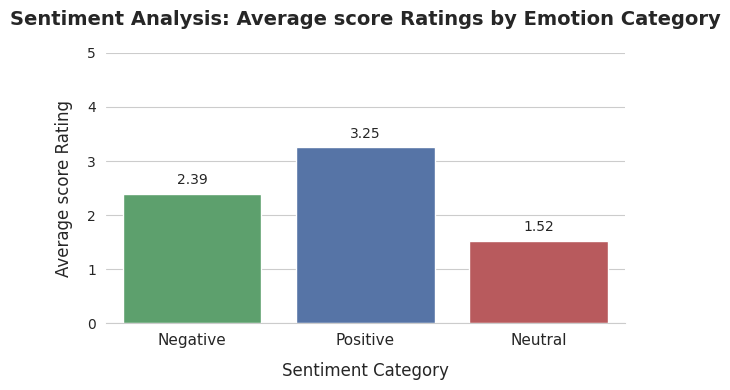

In [19]:
plt.figure(figsize=(6, 4))
sns.set_style("whitegrid")

ax = sns.barplot(data=df,
                 x="Sentiment_Label",
                 y="score",
                 estimator="mean",
                 palette={"pos": "#4c72b0", "neg": "#c44e52", "neutral": "#55a868"},
                 saturation=0.8,
                 ci=None)

plt.title("Sentiment Analysis: Average score Ratings by Emotion Category",
          fontsize=14, pad=20, fontweight='bold')
plt.xlabel("Sentiment Category", fontsize=12, labelpad=10)
plt.ylabel("Average score Rating", fontsize=12, labelpad=10)
plt.ylim(0, 5)  # Assuming score ratings are 1-5 scale

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 10),
                textcoords='offset points',
                fontsize=10)

ax.set_xticklabels(["Negative", "Positive", "Neutral"], fontsize=11)
sns.despine(left=True)
plt.tight_layout()
plt.show()

In [20]:
df["Sentiment_Label"].value_counts()

Sentiment_Label
pos        42662
neg        24573
neutral     7650
Name: count, dtype: int64

Train Test Split

In [21]:
X = df["content"].values
y = df["Sentiment_Label"].values

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2 ,random_state=42)

Logistic Regression

In [23]:
operations = [("vectorizer", TfidfVectorizer()), ("logistic", LogisticRegression(class_weight='balanced'))]

log_model = Pipeline(steps=operations)

log_model.fit(X_train, y_train)

Pipeline(steps=[('vectorizer', TfidfVectorizer()),
                ('logistic', LogisticRegression(class_weight='balanced'))])

In [24]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)

    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

In [25]:
eval_metric(log_model, X_train, y_train, X_test, y_test)

Test_Set
[[4214  260  441]
 [  48 1460   22]
 [1033  377 7122]]
              precision    recall  f1-score   support

         neg       0.80      0.86      0.83      4915
     neutral       0.70      0.95      0.81      1530
         pos       0.94      0.83      0.88      8532

    accuracy                           0.85     14977
   macro avg       0.81      0.88      0.84     14977
weighted avg       0.87      0.85      0.86     14977


Train_Set
[[17511   853  1294]
 [  127  5962    31]
 [ 3477  1445 29208]]
              precision    recall  f1-score   support

         neg       0.83      0.89      0.86     19658
     neutral       0.72      0.97      0.83      6120
         pos       0.96      0.86      0.90     34130

    accuracy                           0.88     59908
   macro avg       0.84      0.91      0.86     59908
weighted avg       0.89      0.88      0.88     59908



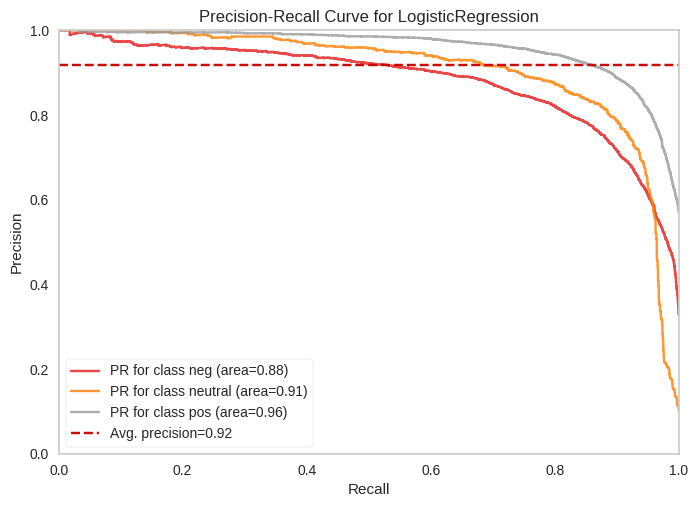

In [26]:

from yellowbrick.classifier import PrecisionRecallCurve

viz = PrecisionRecallCurve(
    log_model,
    classes = np.unique(y_train),
    per_class=True,
    cmap="Set1"
)
viz.fit(X_train, y_train)
viz.score(X_test, y_test)
viz.show();

Text Vectorization and Dataset Preparation

In [27]:
df = df[['content','score']]

In [28]:
df['content'] = df['content'].str.lower()

In [29]:
df['score'] = df['score'].apply(lambda x: 0 if x > 3 else 1)

In [30]:
import requests
stopwords_list = requests.get("https://gist.githubusercontent.com/rg089/35e00abf8941d72d419").content
stopwords = set(stopwords_list.decode().splitlines())
print(stopwords)
for word in stopwords:
    Word = " "+word+" "
    df['content'] = df['content'].str.replace(Word, ' ')

ConnectionError: HTTPSConnectionPool(host='gist.githubusercontent.com', port=443): Max retries exceeded with url: /rg089/35e00abf8941d72d419 (Caused by NameResolutionError("<urllib3.connection.HTTPSConnection object at 0x7cf067793250>: Failed to resolve 'gist.githubusercontent.com' ([Errno -3] Temporary failure in name resolution)"))

In [ ]:
# from sklearn.feature_extraction.text import CountVectorizer
# from sklearn.model_selection import train_test_split, cross_val_score
# cv = CountVectorizer(max_features=10-000)
# x = cv.fit_transform(df['content']).toarray()
# y = df['score']
# x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.8, random_state=21)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split,cross_val_score

tv = TfidfVectorizer(max_features=10000)
x = tv.fit_transform(df['content']).toarray()
y = df['score']
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.2, random_state=43)

In [ ]:
tv.get_feature_names_out()

 Confusion Matrix

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

def model_evaluation(model):
  y_pred = model.predict(X_test)
  cm = confusion_matrix(y_test, y_pred)
  cm_matrix  = pd.DataFrame(data=cm, columns=['Actual Positive:1', 'Actual Negative:0'],
                                 index=['Predict Positive:1', 'Predict Negative:0'])

  print(classification_report(y_test, y_pred))
  sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')
  TP = cm[0,0]
  TN = cm[1,1]
  FP = cm[1,0]
  FN = cm[0,1]
  print('Accuracy: ',(TP + TN) / (TP + TN + FP + FN))
  print('Classification Error : ',(FP + FN)/ float(TP + TN + FP + FN),"\n")
  plt.show()
  print("\n","\n")
  def fit_model(models,cross_val=False,cv_val=4):
    for i in models:
      model = models[i]
      model.fit(X_train, y_train)
      print(i,"\n")
      model_evaluation(model)
      if cross_val:
        cv = cross_val_score(model, X, Y, cv=cv_val)
        print("Cross Validation : ",cv)
        print("Cross Validation Score : ", np.mean(cv))
        print("\n", "\n")

Model Training

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Assuming 'df' DataFrame and 'score' column exist from previous steps
# Define y
y = df['score']

# 1. Encode the labels FIRST
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # Convert ['neg','neutral','pos'] to [0,1,2]

# Assuming 'X' contains the vectorized data from cell AyTouRyzidJm
# 2. Split the data (using encoded y and vectorized X)
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, # Use the vectorized X directly
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded  # Maintain class distribution
)

# Remove redundant reassignments
# X_train_tfidf = X_train
# X_test_tfidf = X_test


# 3. Define and train models
# Ensure xgb is imported if XGBoost is used
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

models = {
    'Logistic Regression': LogisticRegression(),
    'Random Forest': RandomForestClassifier(),
    'XGBoost': xgb.XGBClassifier()
}

for name, model in models.items():
    # Use X_train and X_test directly as they now contain the vectorized data
    model.fit(X_train, y_train_encoded)
    print(f"{name} trained successfully.")

Model Testing

In [ ]:
for name, model in models.items():
    y_pred_encoded = model.predict(X_test_tfidf)
    print(f"\n--- {name} ---")
    print(classification_report(y_test_encoded, y_pred_encoded))  # Use encoded y_test
    print(f"Accuracy: {accuracy_score(y_test_encoded, y_pred_encoded):.2f}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


# Update your model_evaluation function to handle text data
def model_evaluation(model, X_test, y_test):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Get unique class labels from y_test and y_pred
    unique_labels = sorted(list(set(y_test).union(set(y_pred))))

    cm_matrix = pd.DataFrame(data=cm,
                           columns=[f'Predicted:{label}' for label in unique_labels],
                           index=[f'Actual:{label}' for label in unique_labels])


    print(classification_report(y_test, y_pred))
    sns.heatmap(cm_matrix, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {type(model).__name__}')

    # Calculate TP, TN, FP, FN only for binary classification if needed,
    # or adapt for multiclass if applicable to your metric definition
    # For multiclass, accuracy can be calculated directly from classification_report or using accuracy_score
    accuracy = accuracy_score(y_test, y_pred)
    print('Accuracy:', accuracy)
    # Classification error for multiclass can be 1 - accuracy
    print('Classification Error:', 1 - accuracy, "\n")
    plt.show()
    print("\n" * 2)


def fit_models(models, X_train, y_train, X_test, y_test, cross_val=False, cv_val=4):
    for model_name in models:
        # Remove TfidfVectorizer from the pipeline as the data is already vectorized
        model = models[model_name]

        model.fit(X_train, y_train)
        print(f"{model_name}\n{'=' * len(model_name)}")
        model_evaluation(model, X_test, y_test)
        if cross_val:
            # Cross-validation needs to be on the full pipeline
            # Use X_train, y_train for CV fitting
            cv = cross_val_score(model, X_train, y_train, cv=cv_val)
            print("Cross Validation Scores:", cv)
            print("Mean CV Score:", np.mean(cv))
            print("\n" * 2)

# Example usage:
# Assuming you have text data in X_train, X_test and labels in y_train, y_test
# First split your data (if not already done)
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(text_data, labels, test_size=0.2)

# Define your models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'), # Add use_label_encoder and eval_metric for XGBoost with multiclass
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

# Call the function with your data
# Assuming X_train, y_train, X_test, y_test are already defined from previous steps
# Ensure X_train and X_test are vectorized before calling fit_models
fit_models(models, X_train, y_train_encoded, X_test, y_test_encoded)